# Fraud Detection — Modeling
This notebook covers:
- Handling class imbalance (SMOTE, undersampling, class weights)
- Training Logistic Regression, Random Forest, and XGBoost
- Evaluating models using PR-AUC, ROC-AUC, and Confusion Matrix
- Selecting the best model for deployment

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df= pd.read_csv("../data/creditcard.csv")

# Scale Amount and Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Amount', 'Time'], axis=1)

# Split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ready to model!")

Ready to model!


In [11]:
# defining model evaluation function

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay)

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {model_name} Results")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
    print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
    print(f"PR-AUC Score:   {average_precision_score(y_test, y_prob):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return y_prob


  Logistic Regression Results
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score:  0.9573
PR-AUC Score:   0.7439


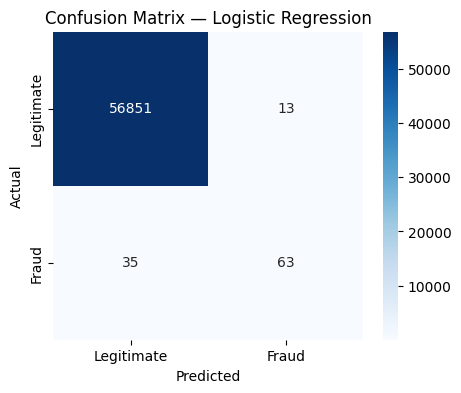

In [12]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_probs = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")


  Logistic Regression (Weighted) Results
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC Score:  0.9722
PR-AUC Score:   0.7189


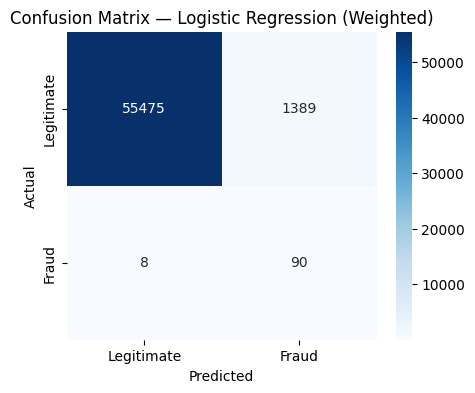

array([0.00565438, 0.06834585, 0.0001205 , ..., 0.00027014, 0.00391637,
       0.08495059], shape=(56962,))

In [13]:
# handling class imbalance
# approach 1: Class Weights
lr_weighted = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  
)
lr_weighted.fit(X_train, y_train)
evaluate_model(lr_weighted, X_test, y_test, "Logistic Regression (Weighted)")

After undersampling:
Class
0    394
1    394
Name: count, dtype: int64

  Logistic Regression (Undersampled) Results
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

ROC-AUC Score:  0.9760
PR-AUC Score:   0.6778


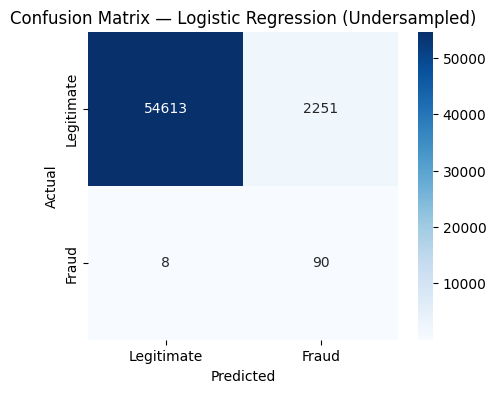

array([4.73022657e-03, 7.15754962e-02, 1.64432155e-02, ...,
       8.36202185e-05, 4.57621526e-03, 1.61452940e-01], shape=(56962,))

In [14]:
# approach 2 : Undersampling

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("After undersampling:")
print(pd.Series(y_train_under).value_counts())

lr_under = LogisticRegression(max_iter=1000, random_state=42)
lr_under.fit(X_train_under, y_train_under)
evaluate_model(lr_under, X_test, y_test, "Logistic Regression (Undersampled)")

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

  Logistic Regression (SMOTE) Results
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score:  0.9698
PR-AUC Score:   0.7249


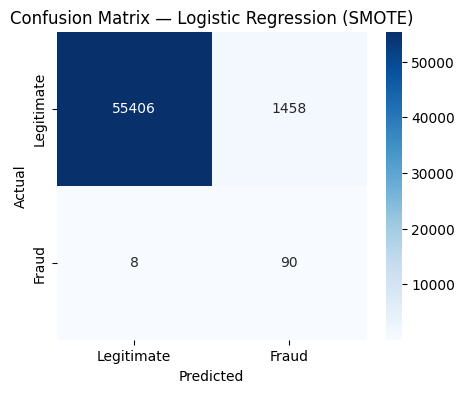

array([2.56149992e-03, 4.96801508e-02, 9.50084647e-06, ...,
       2.18543167e-04, 8.64768695e-04, 4.99390517e-02], shape=(56962,))

In [15]:
# approach 3 : SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())
# You'll see both classes are now equal!

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
evaluate_model(lr_smote, X_test, y_test, "Logistic Regression (SMOTE)")


  Random Forest Results
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score:  0.9688
PR-AUC Score:   0.8678


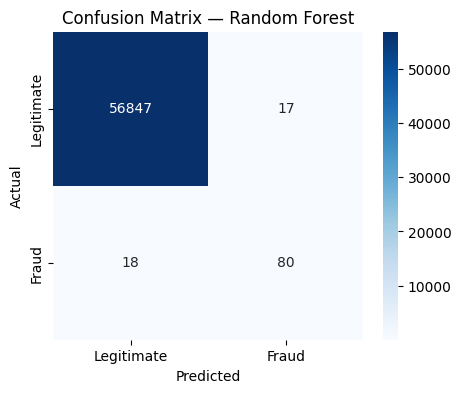

In [18]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # uses all CPU cores — faster training
)
rf_model.fit(X_train_smote, y_train_smote)
rf_probs = evaluate_model(rf_model, X_test, y_test, "Random Forest")


  XGBoost Results
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score:  0.9760
PR-AUC Score:   0.8270


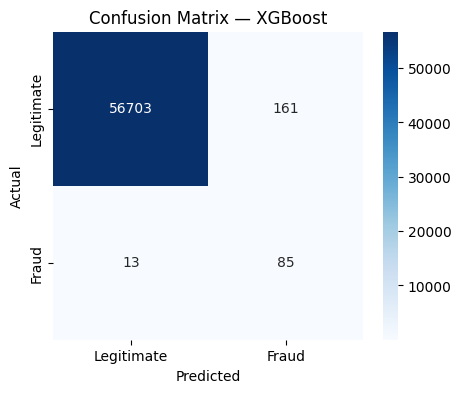

In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='aucpr',  # PR-AUC as eval metric
    n_jobs=-1
)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_probs = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

In [21]:
import os
print(os.getcwd())
print(os.listdir('.'))

D:\fraud-detection\notebooks
['.ipynb_checkpoints', '01_EDA.ipynb', '02_modeling.ipynb']


In [22]:
import joblib

# Save model and scaler
joblib.dump(xgb_model, 'models/fraud_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Model saved!")

Model saved!


In [23]:
from sklearn.metrics import average_precision_score, roc_auc_score

models = {
    "Logistic Regression": lr_model,
    "LR + Class Weights": lr_weighted,
    "LR + SMOTE": lr_smote,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}

results = []
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "PR-AUC": round(average_precision_score(y_test, y_prob), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
print(results_df)

                 Model  PR-AUC  ROC-AUC
3        Random Forest  0.8678   0.9688
4              XGBoost  0.8270   0.9760
0  Logistic Regression  0.7439   0.9573
2           LR + SMOTE  0.7249   0.9698
1   LR + Class Weights  0.7189   0.9722


Random Forest: PR-AUC = 0.8678
XGBoost: PR-AUC = 0.8270
